# Model for Bioreactor
## Import relevant packages

In [4]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from diffrax import ODETerm, SaveAt, diffeqsolve, DirectAdjoint, Kvaerno5, PIDController
import scienceplots
import seaborn as sb
import pandas as pd
import numpy as np
import optimistix as opx
import equinox as eqx
import scipy as sp
import gpjax as gpx
import optax as oax

rng_key = jr.key(48)
np.random.seed(48)

# GPJax uses float64, not float32
jax.config.update("jax_enable_x64", True) 

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
    'font.size': 8,
    'font.sans-serif': 'Times New Roman'
})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'

print(jax.devices())

[CpuDevice(id=0)]


## Define Growth Models and Reactor Material Balance

In [3]:
"""
X: S. cerevisiae
S: Sugar
P: Ethanol

Parameters:
mu_Scerevisiae: Specific growth rate of S. cerevisiae (min-1)
Y_xs_Scerevisiae: Biomass yield coefficient for S. cerevisiae (g biomass / g substrate)
Y_ps_ethanol: Maximum ethanol yield for glucose (g ethanol / g substrate)
K_s_Scerevisiae: Substrate saturation constant for S. cerevisiae (g/L)
K_i_Scerevisiae: Haldane inhibition constant for S. cerevisiae (g/L)

"""

# Monod Mass Balance
def MonodMassBalance(t, y, args):
    X, S, P = y
    
    # Unpack learnable parameters and static experimental conditions
    params, exp_args = args
    
    # Extract physical parameters
    mu_max = params["mu_max_Scerevisiae"]
    Y_xs = params["Y_xs_Scerevisiae"]
    Y_ps = params["Y_ps_ethanol"]
    K_s = params["K_s_Scerevisiae"]
    
    # Extract experimental conditions
    D = exp_args["D"]
    S_in = exp_args["S_in"]

    # Define Monod kinetics
    mu_monod = mu_max * S / (K_s + S)

    # ODEs for bioreactor
    dXdt = (mu_monod - D) * X
    dSdt = D * (S_in - S) - mu_monod / Y_xs * X
    dPdt = Y_ps / Y_xs * mu_monod * X - D * P

    return jnp.stack([dXdt, dSdt, dPdt])

# Haldane Mass Balance
def HaldaneMassBalance(t, y, args):
    X, S, P = y
    
    # Unpack learnable parameters and static experimental conditions
    params, exp_args = args
    
    # Extract physical parameters
    mu_max = params["mu_max_Scerevisiae"]
    Y_xs = params["Y_xs_Scerevisiae"]
    Y_ps = params["Y_ps_ethanol"]
    K_s = params["K_s_Scerevisiae"]
    K_i = params["K_i_Scerevisiae"]
    
    # Extract experimental conditions
    D = exp_args["D"]
    S_in = exp_args["S_in"]

    # Haldane Kinetics (with epsilon to strictly prevent division by zero)
    mu_haldane = mu_max * S / (K_s + S + (S**2 / (K_i + 1e-8)))

    # ODEs for bioreactor
    dXdt = (mu_haldane - D) * X
    dSdt = D * (S_in - S) - (mu_haldane / Y_xs) * X
    dPdt = Y_ps / Y_xs * mu_haldane * X - D * P

    return jnp.stack([dXdt, dSdt, dPdt])

# Define ODE Solver Parameters
MonodTerm = ODETerm(MonodMassBalance)
HaldaneTerm = ODETerm(HaldaneMassBalance)
solver = Kvaerno5()
stepsize_controller = PIDController(rtol=1e-5, atol=1e-5)

# Define Residual Function to minimize
def residuals(log_params, resid_args):

    dataset_list, term, ode_solver, stepsize_controller = resid_args
    
    # Transform parameters to strictly positive 
    real_params = jax.tree_util.tree_map(jnp.exp, log_params)
    
    all_errors = []
    
    for data in dataset_list:
        sol_ys, sol_ts = single_solve(
            data["y0"], 
            data["ts"], 
            data["args"], 
            term, 
            ode_solver, 
            stepsize_controller, 
            real_params
        )
        
        # 0 = Biomass (X), 1 = Substrate (S), 2 = Product (P)
        measured_variable_index = 1  
        
        predicted_y = sol_ys[:, measured_variable_index]
        
        data_error = predicted_y - data["y_true"]

        all_errors.append(data_error.flatten())
    
    # Concatenate all 1D error arrays into one vector
    flat_data_error = jnp.concatenate(all_errors)
    
    # Apply soft bounds / penalties
    mu_max = real_params["mu_max_Scerevisiae"]
    mu_max_penalty = jnp.where(mu_max > 0.4/60, (mu_max - 0.4/60) * 5000.0, 0.0)

    penalty_array = jnp.array([mu_max_penalty])
    
    # Optimistix receives the final concatenated vector of errors + penalties
    return jnp.concatenate([flat_data_error, penalty_array])

# JIT-compiled optimizer
@eqx.filter_jit
def run_optimization(dataset_list, init_log_params, term, ode_solver, stepsize_controller):
    args = (dataset_list, term, ode_solver, stepsize_controller)
    solver_otx = opx.LevenbergMarquardt(rtol=1e-5, atol=1e-5)
    
    result = opx.least_squares(
        residuals,
        solver_otx,
        init_log_params,  
        args=args,
        max_steps=500,  
        throw=False 
    )
    return result

# Define ODE solve
def single_solve(y0, t_data, exp_args, term, ode_solver, stepsize_controller, params):
    # Package parameters and experimental conditions together
    ode_args = (params, exp_args) 
    
    sol = diffeqsolve(
        term, 
        ode_solver, 
        t0=t_data[0], 
        t1=t_data[-1], 
        dt0=1.0, 
        y0=y0, 
        stepsize_controller=stepsize_controller,
        args=ode_args,
        saveat=SaveAt(ts=t_data), 
        max_steps=10_000, 
        adjoint=DirectAdjoint()
    )
    return sol.ys, sol.ts

def get_model_residuals(dataset_list, term, ode_solver, stepsize_controller, params, measured_index=1):
    """
    Simulates all experiments in the dataset and calculates the residuals 
    (Predicted - Observed) for the specified biological variable.
    
    Args:
        dataset_list: pytree experimental data.
        term: Diffrax ODETerm (HaldaneTerm or MonodTerm).
        ode_solver: Diffrax solver (Kvaerno5).
        stepsize_controller: Diffrax PID controller.
        params: Optimized dictionary of strictly positive physical parameters.
        measured_index: 0 for Biomass (X), 1 for Substrate (S), 2 for Product (P).
        
    Returns:
        1D numpy arrays of residuals
    """
    all_experiment_residuals = []
    
    for data in dataset_list:
        # solve ODE at given parameter and experimental condition
        sol_ys, sol_ts = single_solve(
            data["y0"], 
            data["ts"], 
            data["args"], 
            term, 
            ode_solver, 
            stepsize_controller, 
            params
        )
        
        # Slice out only the measured variable
        predicted_y = sol_ys[:, measured_index]
        observed_y = data["y_true"]
        
        # Calculate raw residuals (Predicted - Observed)
        raw_residuals = predicted_y - observed_y
        
        # Append as a standard NumPy array 
        all_experiment_residuals.append(np.array(raw_residuals))
        
    return all_experiment_residuals

# Define a function to get hybrid model residuals
def get_hybrid_residuals(dataset_list, ode_params, gp_posterior, gp_train_data, measured_index=1):
    """
    Calculates residuals for the Hybrid model: Error = (ODE + GP) - Observed
    
    Args:
        dataset_list: pytree of experimental data.
        ode_params: optimized physical parameters for the ODE.
        gp_posterior: The trained GPJax posterior object.
        gp_train_data: The scaled Dataset used to train the GP.
        measured_index: 0 for X, 1 for S, 2 for P.
        
    Returns:
        1D numpy arrays containing hybrid residuals.
    """
    hybrid_residuals_list = []
    start_idx = 0
    
    for data in dataset_list:
        # get ODE values
        sol_ys, _ = single_solve(
            data["y0"], data["ts"], data["args"], 
            MonodTerm, solver, stepsize_controller, ode_params
        )
        ode_preds = sol_ys[:, measured_index]
        
        # extract GP Mean correction
        num_pts = len(data["ts"])
        end_idx = start_idx + num_pts
        
        # predict or slice from the existing mean
        latent_dist = gp_posterior.predict(gp_train_data.X[start_idx:end_idx], train_data=gp_train_data)
        gp_mean_slice = latent_dist.mean.flatten()
        
        # calculate hybrid predictions and residuals
        hybrid_preds = ode_preds + gp_mean_slice
        residuals = hybrid_preds - data["y_true"]
        
        # append residuals to array
        hybrid_residuals_list.append(np.array(residuals))
        
        # Update index for next experiment
        start_idx = end_idx
        
    return hybrid_residuals_list

# Define global parameters

t_eval_model = jnp.linspace(0, 3600, 576)

# Define Shapiro-Wilk check function, Shapiro-Wilk checks for normality
def check_p_shapiro(residuals):

    test_stat, p_value = sp.stats.shapiro(residuals)

    print(f'p value for Shapiro-Wilk: {p_value:.4f}')

    if p_value > 0.05 and p_value <= 1:
        print(f'\np is {p_value:.4f}, the residuals follow the normal distribution.')
    elif p_value > 0 and p_value <= 0.05:
        print(f'\np is {p_value:.4f}, residual does NOT follow the normal distribution.')
    else:
        print('\nError: p-value is not between 0 and 1')

# Define function to calculate model metrics; RMSE, MAE, AIC, BIC
# AIC and BIC formula assumes normal or gaussian likelihood
def get_model_metrics(residuals, k_params):
    # RMSE
    rmse = np.sqrt(np.mean(residuals**2))
    print(f'RMSE: {rmse:.3f}')

    # MAE
    mae = np.mean(np.abs(residuals))
    print(f'MAE: {mae:.3f}')

    # get values for AIC and BIC
    n = len(residuals)
    k = len(k_params)
    rss = np.sum(residuals**2)
    
    # AIC
    aic = 2 * k + n * np.log(np.sum(rss) / n)
    print(f'AIC: {aic:.3f}')

    # BIC
    bic = k * np.log(n) + n * np.log(np.sum(rss) / n)
    print(f'BIC: {bic:.3f}')

## Build Training Dataset for Fitting

In [47]:
run2 = pd.read_csv('raw_data/Run02.csv') # D = 0.216
run3 = pd.read_csv('raw_data/Run03.csv') # D = 0.288
run4 = pd.read_csv('raw_data/Run04.csv') # D = 0.144

run2.rename(columns={'Time (min)': 'Time', 'Concentration (g/L)': 'Sugar_Conc'}, inplace=True)
run3.rename(columns={'Time (min)': 'Time', 'Concentration (g/L)': 'Sugar_Conc'}, inplace=True)
run4.rename(columns={'Time (min)': 'Time', 'Concentration (g/L)': 'Sugar_Conc'}, inplace=True)

print(run2.tail())

     Time  Sugar_Conc
5   120.0   13.326018
6   195.0    9.837171
7  1460.0   13.361259
8  1485.0   13.201073
9  1515.0   13.901085


In [ ]:
"""Get training dataset"""

dataset_train = [
    {
        "y0": jnp.array([11.0, 30.0, 0.0]),
        "ts": jnp.array(run4['Time'].to_numpy()), # Exp 1: 250 data points
        "y_true": jnp.array(run4['Sugar_Conc'].to_numpy()),            # Shape: (250, 3)
        "args": {"D": 0.144 / 60.0, "S_in": 20.0}
    },
    {
        "y0": jnp.array([11.0, 30.0, 0.0]),
        "ts": jnp.array(run3['Time'].to_numpy()), # Exp 2: 400 data points
        "y_true": jnp.array(run3['Sugar_Conc']),            # Shape: (400, 3)
        "args": {"D": 0.288 / 60.0, "S_in": 20.0}
    },
    {
        "y0": jnp.array([11.0, 30.0, 0.0]),
        "ts": jnp.array(run2['Time'].to_numpy()), # Exp 3: 310 data points
        "y_true": jnp.array(run2['Sugar_Conc'].to_numpy()),            # Shape: (310, 3)
        "args": {"D": 0.216 / 60.0, "S_in": 20.0}
    }
]

## Get Validation Dataset

In [49]:
validation_run = pd.read_csv('raw_data/RunV.csv')

validation_run.rename(columns={'Time (min)': 'Time', 'Concentration (g/L)': 'Sugar_Conc'},
                                 inplace=True)

print(validation_run)

     Time  Sugar_Conc
0   130.0    8.409996
1   190.0    6.531016
2   295.0    4.166673
3  1385.0   11.697009
4  1495.0   19.049537
5  1500.0   14.073365


## Optimize Monod Parameters

In [27]:
initial_params_monod = {
    "mu_max_Scerevisiae": jnp.array(0.40 / 60.0),
    "Y_xs_Scerevisiae": jnp.array(0.50),
    "Y_ps_ethanol": jnp.array(0.31),
    "K_s_Scerevisiae": jnp.array(1.21)
}

In [ ]:
# Convert initial guesses to log-space for unconstrained optimization
init_log_params = jax.tree_util.tree_map(jnp.log, initial_params_monod)

print("Running Optimistix Levenberg-Marquardt over variable-length datasets...")
solution = run_optimization(
    dataset_train, init_log_params, MonodTerm, solver, stepsize_controller
)

# Extract and convert final parameters back to physical space
final_params_log = solution.value
monod_final_params = jax.tree_util.tree_map(jnp.exp, final_params_log)

print("\n--- Optimized Parameters ---")
for key, val in monod_final_params.items():
    print(f"{key}: {val:.6f}")

# Export Monod Parameters
np.savez('Params/MonodDict.npz', **monod_final_params)
print("\nDictionary exported to 'Params/MonodDict.npz'")


Running Optimistix Levenberg-Marquardt over variable-length datasets...

--- Optimized Parameters ---
K_s_Scerevisiae: 38.928681
Y_ps_ethanol: 0.310000
Y_xs_Scerevisiae: 0.072280
mu_max_Scerevisiae: 0.006789

Dictionary exported to 'Params/MonodDict.npz'


In [29]:
monod_params_opt = jnp.array(jax.tree_util.tree_leaves(monod_final_params))

monod_params_opt = monod_params_opt*jnp.array([1, 1, 1, 60])

print("Final parameters:")
print(jnp.round(monod_params_opt, decimals=4)) # K_s, Y_ps, Y_xs, mu_max

monod_params_opt = monod_final_params

Final parameters:
[38.9287  0.31    0.0723  0.4073]


In [ ]:
"""Read saved Monod Parameters"""

with np.load('Params/MonodDict.npz') as loaded_data:
    # Reconstruct the dictionary and cast arrays back to JAX
    monod_params_opt = {key: jnp.array(loaded_data[key]) for key in loaded_data.files}

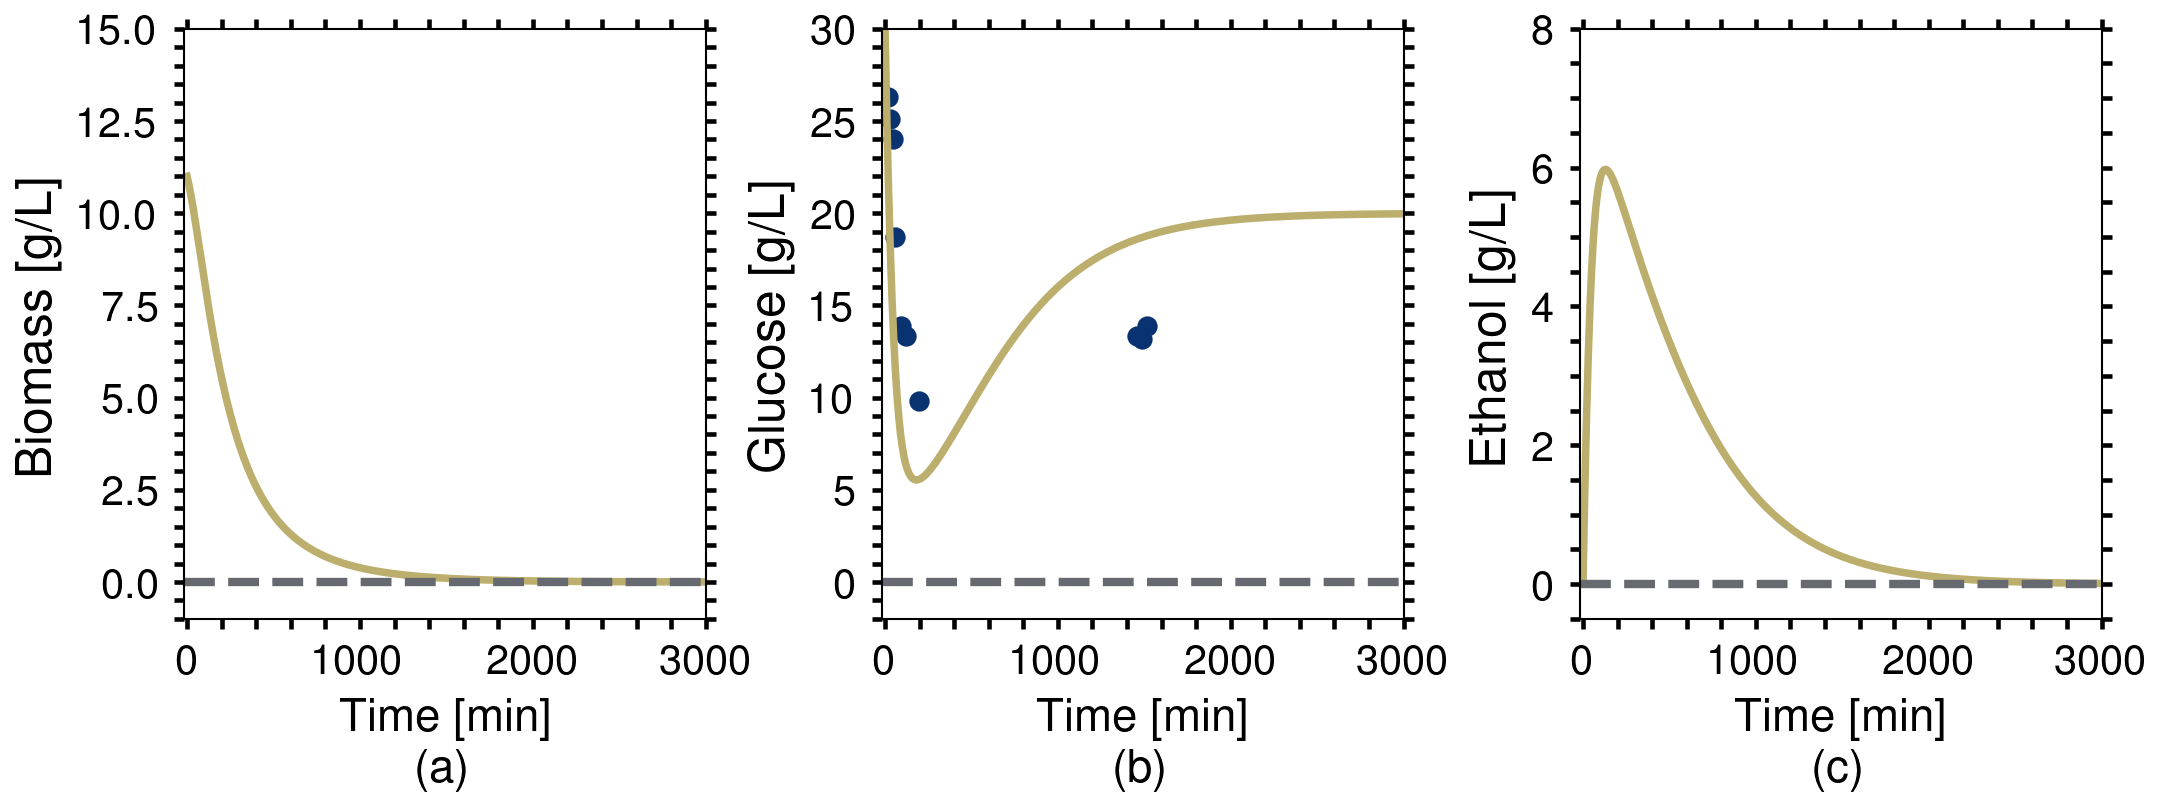

In [ ]:
"""Plot Fitted Monod Model"""

data = {
        "y0": jnp.array([11.0, 30.0, 0.0]),
        "ts": jnp.array(run2['Time'].to_numpy()), # Experiment Dataset
        "args": {"D": 0.288 / 60.0, "S_in": 20.0}
    }

args = (monod_params_opt, data["args"])

sol = diffeqsolve(
        MonodTerm, 
        solver, 
        t0=0, # Start time
        t1=3000, # End time
        dt0=1.0,               
        y0=data['y0'], # Initial biological concentrations [X0, S0, P0]
        stepsize_controller=stepsize_controller,
        args=args,
        saveat=SaveAt(ts=np.linspace(0, 3000, 600)), 
        max_steps=10_000
    )

# use scienceplots
plt.style.use(['science','nature'])

# use cividis cmap for colorblind friendly colors
cmap = sb.color_palette('cividis', as_cmap=True)

fig, (a1, a2, a3) = plt.subplots(figsize=(7.2, 2.8), nrows = 1, ncols = 3)

# axes 1: biomass 
a1.plot(sol.ts, sol.ys[:,0], linewidth=1.8, color=cmap(0.75))
a1.axhline(0, ls='--', lw=2, color=cmap(0.4))
a1.set_xlim(-15, 3000)
a1.set_ylim(-1, 15)
a1.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a1.set_xlabel('Time [min] \n (a)', fontsize=11.0)
a1.set_ylabel('Biomass [g/L]', fontsize=12.0)

# axes 2: glucose
a2.plot(sol.ts, sol.ys[:,1], linewidth=1.8, color=cmap(0.75))
a2.scatter(run2['Time'], run2['Sugar_Conc'], s=15, color=cmap(0.1))
a2.axhline(0, ls='--', lw=2, color=cmap(0.4))
a2.set_xlim(-15, 3000)
a2.set_ylim(-2, 30)
a2.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a2.set_xlabel('Time [min] \n (b)', fontsize=11.0)
a2.set_ylabel('Glucose [g/L]', fontsize=12.0)

# axes 3: ethanol
a3.plot(sol.ts, sol.ys[:,2], linewidth=1.8, color=cmap(0.75))
a3.axhline(0, ls='--', lw=2, color=cmap(0.4))
a3.set_xlim(-15, 3000)
a3.set_ylim(-0.5, 8)
a3.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a3.set_xlabel('Time [min] \n (c)', fontsize=11.0)
a3.set_ylabel('Ethanol [g/L]', fontsize=12.0)

plt.grid(False)
plt.tight_layout()

filename = 'run_monod'
#plt.savefig(f'plots_svg/{filename}.svg') # save as .svg
#plt.savefig(f'plots_eps/{filename}.eps') # save as .eps
plt.show()

## Optimize Haldane Parameters

In [30]:
initial_params_haldane = {
    "mu_max_Scerevisiae": jnp.array(0.40 / 60.0),
    "Y_xs_Scerevisiae": jnp.array(0.50),
    "Y_ps_ethanol": jnp.array(0.31),
    "K_s_Scerevisiae": jnp.array(1.51),
    "K_i_Scerevisiae": jnp.array(0.80)
}

In [ ]:
# Convert initial guesses to log-space for unconstrained optimization
init_log_params = jax.tree_util.tree_map(jnp.log, initial_params_haldane)
print("Running Optimistix Levenberg-Marquardt over variable-length datasets...")
solution = run_optimization(dataset_train, init_log_params, HaldaneTerm, solver, stepsize_controller)

# Extract and convert final parameters back to physical space
final_params_log = solution.value
haldane_final_params = jax.tree_util.tree_map(jnp.exp, final_params_log)

print("\n--- Optimized Parameters ---")
for key, val in haldane_final_params.items():
    print(f"{key}: {val:.6f}")

# Export Monod Parameters
np.savez('Params/HaldaneDict.npz', **haldane_final_params)
print("\nDictionary exported to 'Params/HaldaneDict.npz'")

Running Optimistix Levenberg-Marquardt over variable-length datasets...

--- Optimized Parameters ---
K_i_Scerevisiae: 65476700267.552483
K_s_Scerevisiae: 38.928677
Y_ps_ethanol: 0.310000
Y_xs_Scerevisiae: 0.072280
mu_max_Scerevisiae: 0.006789

Dictionary exported to 'Params/HaldaneDict.npz'


In [32]:
haldane_params_opt = jnp.array(jax.tree_util.tree_leaves(haldane_final_params))

haldane_params_opt = haldane_params_opt*jnp.array([1, 1, 1, 1, 60])

print("Final parameters:")
print(jnp.round(haldane_params_opt, decimals=4)) # K_s, Y_ps, Y_xs, mu_max

haldane_params_opt = haldane_final_params

Final parameters:
[6.54767003e+10 3.89287000e+01 3.10000000e-01 7.23000000e-02
 4.07300000e-01]


In [ ]:
"""Read saved Haldane Parameters"""

with np.load('Params/HaldaneDict.npz') as loaded_data:
    # Reconstruct the dictionary and cast arrays back to JAX
    haldane_params_opt = {key: jnp.array(loaded_data[key]) for key in loaded_data.files}

print(haldane_params_opt)

{'K_i_Scerevisiae': Array(6.54767003e+10, dtype=float64), 'K_s_Scerevisiae': Array(38.92867726, dtype=float64), 'Y_ps_ethanol': Array(0.31, dtype=float64), 'Y_xs_Scerevisiae': Array(0.07228035, dtype=float64), 'mu_max_Scerevisiae': Array(0.00678855, dtype=float64)}


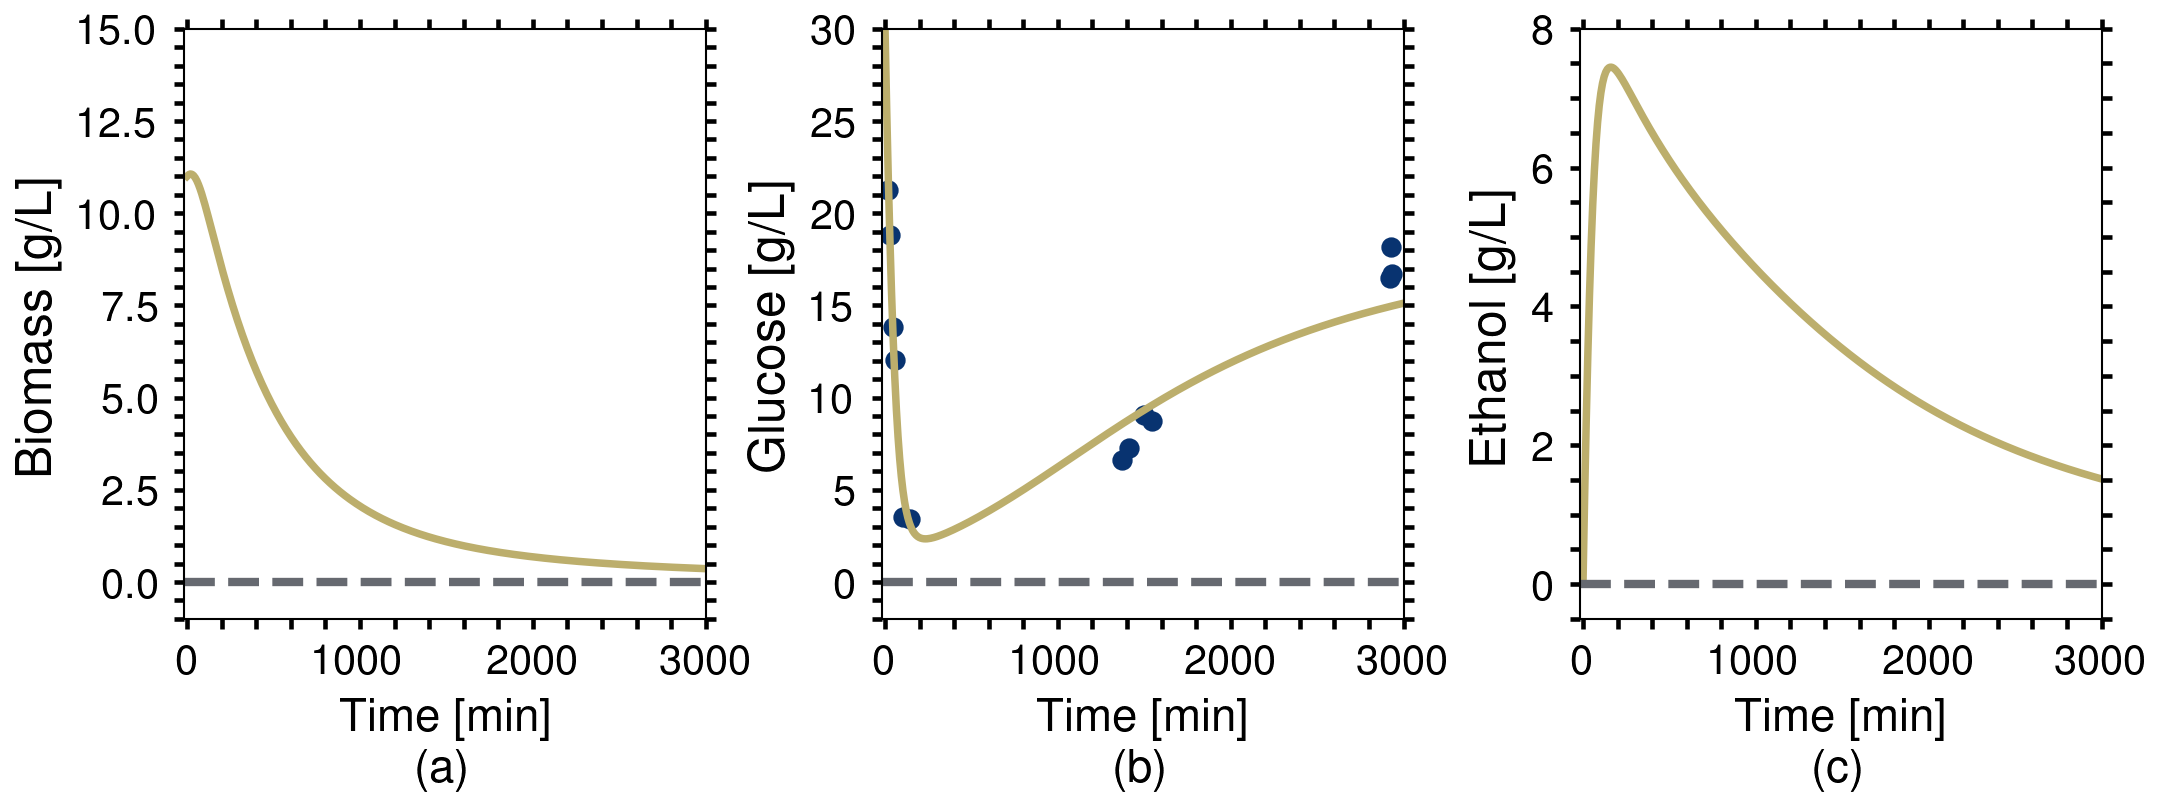

In [ ]:
"""Plot Haldane Fit for D = 0.144"""

data = {
        "y0": jnp.array([11.0, 30.0, 0.0]),
        "ts": jnp.array(run4['Time'].to_numpy()), # Exp 
        "args": {"D": 0.144 / 60.0, "S_in": 20.0}
    }

args = (haldane_params_opt, data["args"])

sol = diffeqsolve(
        HaldaneTerm, 
        solver, 
        t0=0, # Start time
        t1=3000, # End time
        dt0=1.0,               
        y0=data['y0'], # Initial biological concentrations [X0, S0, P0]
        stepsize_controller=stepsize_controller,
        args=args,         
        saveat=SaveAt(ts=np.linspace(0, 3000, 320)),
    )

# use scienceplots
plt.style.use(['science','nature'])

# use cividis cmap for colorblind friendly
cmap = sb.color_palette('cividis', as_cmap=True)

fig, (a1, a2, a3) = plt.subplots(figsize=(7.2, 2.8), nrows = 1, ncols = 3)

# axes 1: Biomass
a1.plot(sol.ts, sol.ys[:,0], linewidth=1.8, color=cmap(0.75))
a1.axhline(0, ls='--', lw=2, color=cmap(0.4))
a1.set_xlim(-15, 3000)
a1.set_ylim(-1, 15)
a1.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a1.set_xlabel('Time [min] \n (a)', fontsize=11.0)
a1.set_ylabel('Biomass [g/L]', fontsize=12.0)

# axes 2: glucose
a2.plot(sol.ts, sol.ys[:,1], linewidth=1.8, color=cmap(0.75))
a2.scatter(run4['Time'], run4['Sugar_Conc'], s=15, color=cmap(0.1))
a2.axhline(0, ls='--', lw=2, color=cmap(0.4))
a2.set_xlim(-15, 3000)
a2.set_ylim(-2, 30)
a2.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a2.set_xlabel('Time [min] \n (b)', fontsize=11.0)
a2.set_ylabel('Glucose [g/L]', fontsize=12.0)

# axes 3: ethanol
a3.plot(sol.ts, sol.ys[:,2], linewidth=1.8, color=cmap(0.75))
a3.axhline(0, ls='--', lw=2, color=cmap(0.4))
a3.set_xlim(-15, 3000)
a3.set_ylim(-0.5, 8)
a3.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a3.set_xlabel('Time [min] \n (c)', fontsize=11.0)
a3.set_ylabel('Ethanol [g/L]', fontsize=12.0)

plt.grid(False)
plt.tight_layout()

filename = 'run4_haldane'
#plt.savefig(f'plots_svg/{filename}.svg') # save as .svg
#plt.savefig(f'plots_eps/{filename}.eps') # save as .eps
plt.show()

## Evaluate Fitted Empirical Models

### Evaluate Fitted Monod Model

In [ ]:
monod_train_residuals = get_model_residuals(dataset_train, MonodTerm, solver, 
                                            stepsize_controller, monod_params_opt, 
                                            measured_index=1)

print('Monod Model Metrics at D = 0.144')
res_monod_144 = monod_train_residuals[0]
check_p_shapiro(res_monod_144)

print('\nMonod Model Metrics at D = 0.288')
res_monod_288 = monod_train_residuals[1]
check_p_shapiro(res_monod_288)

print('\nMonod Model Metrics at D = 0.216')
res_monod_216 = monod_train_residuals[2]
check_p_shapiro(res_monod_216)


"""
Test is done under H0: residuals follow normal distribution

--> p < 0.05; reject H0, residuals don't follow normal distribution
"""

Monod Model Metrics at D = 0.144
p value for Shapiro-Wilk: 0.7508

p is 0.7508, the residuals follow the normal distribution.

Monod Model Metrics at D = 0.288
p value for Shapiro-Wilk: 0.1439

p is 0.1439, the residuals follow the normal distribution.

Monod Model Metrics at D = 0.216
p value for Shapiro-Wilk: 0.1049

p is 0.1049, the residuals follow the normal distribution.


"\nTest is done under H0: residuals follow normal distribution\n\n--> p < 0.05; reject H0, residuals don't follow normal distribution\n"

In [15]:
"""
Check for RMSE, MAE, AIC, and BIC for Monod
"""

print('Monod Model Metrics at D = 0.144')
res_monod_144 = monod_train_residuals[0]
get_model_metrics(res_monod_144, monod_params_opt)

print('\nMonod Model Metrics at D = 0.288')
res_monod_288 = monod_train_residuals[1]
get_model_metrics(res_monod_288, monod_params_opt)

print('\nMonod Model Metrics at D = 0.216')
res_monod_216 = monod_train_residuals[2]
get_model_metrics(res_monod_216, monod_params_opt)

Monod Model Metrics at D = 0.144
RMSE: 3.889
MAE: 2.969
AIC: 43.311
BIC: 45.571

Monod Model Metrics at D = 0.288
RMSE: 6.997
MAE: 5.417
AIC: 46.909
BIC: 48.119

Monod Model Metrics at D = 0.216
RMSE: 4.487
MAE: 4.039
AIC: 38.022
BIC: 39.233


### Evaluate Fitted Haldane Model

In [ ]:
haldane_train_residuals = get_model_residuals(dataset_train, HaldaneTerm, solver, 
                                            stepsize_controller, haldane_params_opt, 
                                            measured_index=1)

print('Haldane Model Metrics at D = 0.144')
res_haldane_144 = haldane_train_residuals[0]
check_p_shapiro(res_haldane_144)

print('\nHaldane Model Metrics at D = 0.288')
res_haldane_288 = haldane_train_residuals[1]
check_p_shapiro(res_haldane_288)

print('\nHaldane Model Metrics at D = 0.216')
res_haldane_216 = haldane_train_residuals[2]
check_p_shapiro(res_haldane_216)

"""
Test is done under H0: residuals follow normal distribution

--> p < 0.05; reject H0, residuals don't follow normal distribution
"""

Haldane Model Metrics at D = 0.144
p value for Shapiro-Wilk: 0.7508

p is 0.7508, the residuals follow the normal distribution.

Haldane Model Metrics at D = 0.288
p value for Shapiro-Wilk: 0.1439

p is 0.1439, the residuals follow the normal distribution.

Haldane Model Metrics at D = 0.216
p value for Shapiro-Wilk: 0.1049

p is 0.1049, the residuals follow the normal distribution.


"\nTest is done under H0: residuals follow normal distribution\n\n--> p < 0.05; reject H0, residuals don't follow normal distribution\n"

In [27]:
"""
Check for RMSE, MAE, AIC, and BIC for Haldane
"""

print('Haldane Model Metrics at D = 0.144')
res_haldane_144 = haldane_train_residuals[0]
get_model_metrics(res_haldane_144, haldane_params_opt)

print('\nHaldane Model Metrics at D = 0.288')
res_haldane_288 = haldane_train_residuals[1]
get_model_metrics(res_haldane_288, haldane_params_opt)

print('\nHaldane Model Metrics at D = 0.216')
res_haldane_216 = haldane_train_residuals[2]
get_model_metrics(res_haldane_216, haldane_params_opt)

Haldane Model Metrics at D = 0.144
RMSE: 3.889
MAE: 2.969
AIC: 45.311
BIC: 48.136

Haldane Model Metrics at D = 0.288
RMSE: 6.997
MAE: 5.417
AIC: 48.909
BIC: 50.422

Haldane Model Metrics at D = 0.216
RMSE: 4.487
MAE: 4.039
AIC: 40.022
BIC: 41.535


## Residual Modelling via Gaussian Process

### Monod GP

In [ ]:
# GP learn based on Time & Dilution Rate
X_global = []
y_global = []

for i, data in enumerate(dataset_train):
    # time points
    t_points = jnp.array(data["ts"]).reshape(-1, 1)
    
    # Dilution rate and create an array of the same length as t_points
    D_val = data["args"]["D"]
    D_points = jnp.full_like(t_points, D_val)
    
    # combine time and dilution rate into a 2D input feature matrix [Time, Dilution]
    X_exp = jnp.hstack([t_points, D_points])
    
    X_global.append(X_exp)
    y_global.append(monod_train_residuals[i].reshape(-1, 1)) # From residual function

# concatenate everything into one dataset for GPJax
X_monod_gp = jnp.vstack(X_global)
y_monod_gp = jnp.vstack(y_global)

# create the GPJax Dataset
gp_dataset_monod = gpx.Dataset(X=X_monod_gp, y=y_monod_gp)

print(f"GPJax Input Shape (X): {gp_dataset_monod.n}, {gp_dataset_monod.in_dim}")
print(f"GPJax Output Shape (y): {gp_dataset_monod.y.shape[0]}, {gp_dataset_monod.y.shape[1]}")

GPJax Input Shape (X): 33, 2
GPJax Output Shape (y): 33, 1


In [ ]:
# define GP kernel; use Matern 3/2
kernel = gpx.kernels.Matern32(
    active_dims=[0, 1], 
    lengthscale=jnp.array([15.0, 10.0]),
    variance=1.0 
)

# define mean function, priors, and likelihood
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=gp_dataset_monod.n)
posterior = prior * likelihood

In [ ]:
def objective(params, data):
    return -gpx.objectives.conjugate_mll(params, data)

# op[timize
optimizer = oax.adam(learning_rate=0.01)

opt_posterior, history = gpx.fit(
    model=posterior,
    objective=objective,
    train_data=gp_dataset_monod,
    optim=optimizer,
    num_iters=1000, 
    key=rng_key
)

Running: 100%|██████████| 1000/1000 [00:00<00:00, 1038.96it/s, Value=99.31]


In [56]:
latent_dist = opt_posterior.predict(X_monod_gp, train_data=gp_dataset_monod)
predictive_dist = opt_posterior.likelihood(latent_dist)

gp_monod_mean = predictive_dist.mean
gp_monod_std = jnp.sqrt(predictive_dist.variance)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


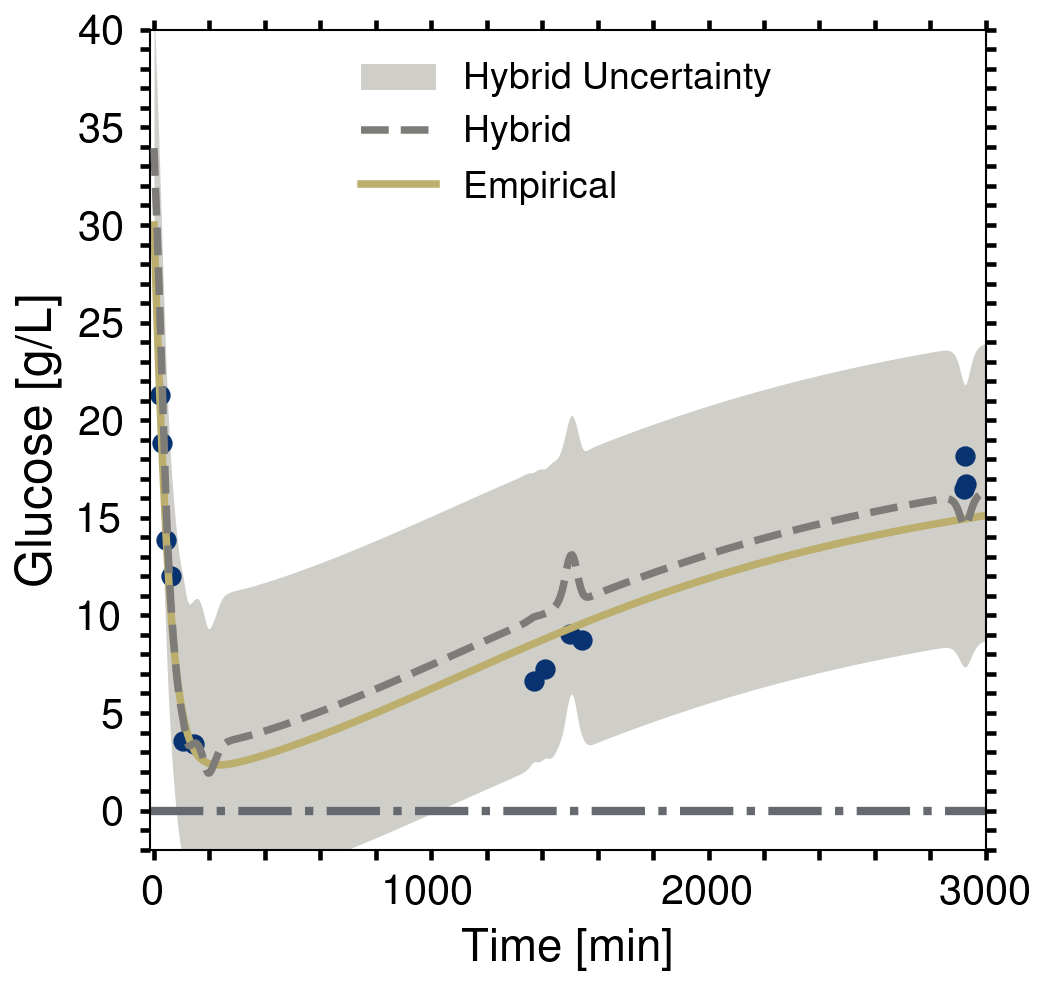

In [ ]:
"""Plot Monod GP Hybrid Fit"""

# experimental data
data = {
    "y0":   jnp.array([11.0, 30.0, 0.0]),
    "ts":   jnp.array(run4['Time'].to_numpy()),
    "args": {"D": 0.144 / 60.0, "S_in": 20.0},
}

# time points for smooth plot
ts_smooth = jnp.linspace(0, 3000, 600)

ys_smooth, _ = single_solve(
    data["y0"],
    ts_smooth,
    data["args"],
    MonodTerm,
    solver,
    stepsize_controller,
    monod_final_params,
)

# GP prediction on smooth
D_val = data["args"]["D"]
X_pred = jnp.hstack([
    ts_smooth.reshape(-1, 1),
    jnp.full((ts_smooth.shape[0], 1), D_val),
])

latent_dist     = opt_posterior.predict(X_pred, train_data=gp_dataset_monod)
predictive_dist = opt_posterior.likelihood(latent_dist)

gp_mean_smooth = predictive_dist.mean
gp_std_smooth  = jnp.sqrt(predictive_dist.variance)

# hybrid prediction for glucose
hybrid_glucose = ys_smooth[:, 1] + gp_mean_smooth
glucose_low     = hybrid_glucose - 1.96 * gp_std_smooth
glucose_high     = hybrid_glucose + 1.96 * gp_std_smooth

# start plotting, use scienceplots
plt.style.use(['science', 'nature'])

# use cividis cmap
cmap = sb.color_palette('cividis', as_cmap=True)

# only plot for glucose
fig, a2 = plt.subplots(figsize=(3.6, 3.4), nrows=1, ncols=1)

# plot hybrid for glucose
a2.fill_between(ts_smooth, glucose_low, glucose_high, color=cmap(0.55), 
                alpha=0.4, linewidth=0, zorder=1, label='Hybrid Uncertainty')
a2.plot(ts_smooth, hybrid_glucose, linewidth=1.8, color=cmap(0.5),
        label='Hybrid', ls='--', zorder=4)

# plot glucose empirical
a2.plot(ts_smooth, ys_smooth[:, 1], linewidth=1.8, color=cmap(0.75), 
        label='Empirical', zorder=2)
a2.scatter(run4['Time'], run4['Sugar_Conc'], s=15, color=cmap(0.1), zorder=1)
a2.axhline(0, ls='-.', lw=2, color=cmap(0.4))
a2.set_xlim(-15, 3000)
a2.set_ylim(-2, 40)
a2.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a2.set_xlabel('Time [min]', fontsize=11.0)
a2.set_ylabel('Glucose [g/L]', fontsize=12.0)
a2.legend(fontsize=9, loc='upper center')

plt.grid(False)
plt.tight_layout()

filename = 'run4_monod_hybrid'
#plt.savefig(f'plots_svg/{filename}.svg') # save as .svg
#plt.savefig(f'plots_eps/{filename}.eps') # save as .eps
plt.show()

In [ ]:
res_hybrid_monod = get_hybrid_residuals(dataset_train, monod_final_params, 
                                        opt_posterior, gp_dataset_monod, 
                                        measured_index=1)

# define number of parameters
hybrid_monod_k_list = list(monod_final_params) + ["gp_len1", "gp_len2", "gp_var"]

print('Hybrid Monod Model Metrics at D = 0.144')
res_monod_hybrid_144 = res_hybrid_monod[0]
get_model_metrics(res_monod_hybrid_144, hybrid_monod_k_list)

print('\nHybrid Monod Model Metrics at D = 0.288')
res_monod_hybrid_288 = res_hybrid_monod[1]
get_model_metrics(res_monod_hybrid_288, hybrid_monod_k_list)

print('\nHybrid Monod Model Metrics at D = 0.216')
res_monod_hybrid_216 = res_hybrid_monod[2]
get_model_metrics(res_monod_hybrid_216, hybrid_monod_k_list)

Hybrid Monod Model Metrics at D = 0.144
RMSE: 5.639
MAE: 4.434
AIC: 58.970
BIC: 62.925

Hybrid Monod Model Metrics at D = 0.288
RMSE: 9.809
MAE: 7.550
AIC: 59.665
BIC: 61.783

Hybrid Monod Model Metrics at D = 0.216
RMSE: 5.543
MAE: 5.221
AIC: 48.250
BIC: 50.368


### Haldane GP

In [ ]:
# GP learn based on Time & Dilution Rate
X_global = []
y_global = []

for i, data in enumerate(dataset_train):
    # get time points
    t_points = jnp.array(data["ts"]).reshape(-1, 1)
    
    # get Dilution rate and create an array of the same length as t_points
    D_val = data["args"]["D"]
    D_points = jnp.full_like(t_points, D_val)
    
    # combine time and dilution rate into a 2D input feature matrix [Time, Dilution]
    X_exp = jnp.hstack([t_points, D_points])
    
    X_global.append(X_exp)
    y_global.append(haldane_train_residuals[i].reshape(-1, 1)) # From residual function

# concatenate everything into one giant dataset for GPJax
X_haldane_gp = jnp.vstack(X_global)
y_haldane_gp = jnp.vstack(y_global)

# create the GPJax Dataset
gp_dataset_haldane = gpx.Dataset(X=X_haldane_gp, y=y_haldane_gp)

print(f"GPJax Input Shape (X): {gp_dataset_haldane.n}, {gp_dataset_haldane.in_dim}")
print(f"GPJax Output Shape (y): {gp_dataset_haldane.y.shape[0]}, {gp_dataset_haldane.y.shape[1]}")

GPJax Input Shape (X): 33, 2
GPJax Output Shape (y): 33, 1


In [ ]:
# define GP kernel, use Matern 3/2
kernel = gpx.kernels.Matern32(
    active_dims=[0, 1], 
    lengthscale=jnp.array([15.0, 10.0]),
    variance=1.0 
)

# define mean function, prior, and likelihood
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=gp_dataset_haldane.n)
posterior = prior * likelihood

In [ ]:
def objective(params, data):
    return -gpx.objectives.conjugate_mll(params, data)

# optimize
optimizer = oax.adam(learning_rate=0.01)

opt_posterior, history = gpx.fit(
    model=posterior,
    objective=objective,
    train_data=gp_dataset_monod,
    optim=optimizer,
    num_iters=1000, 
    key=rng_key
)

Running: 100%|██████████| 1000/1000 [00:01<00:00, 988.87it/s, Value=99.24] 


In [95]:
latent_dist = opt_posterior.predict(X_haldane_gp, train_data=gp_dataset_haldane)
predictive_dist = opt_posterior.likelihood(latent_dist)

gp_haldane_mean = predictive_dist.mean
gp_haldane_std = jnp.sqrt(predictive_dist.variance)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


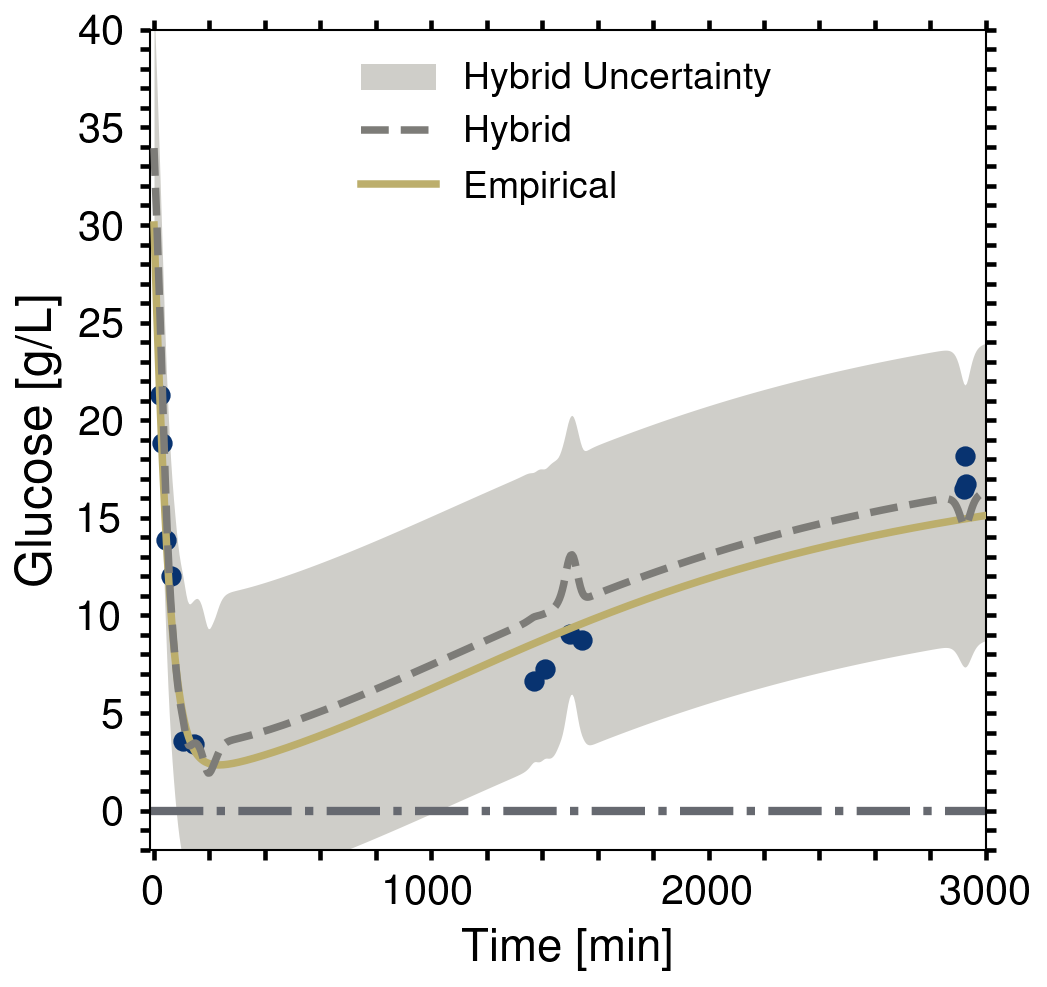

In [ ]:
"""Plot Monod GP Hybrid Fit — run4"""

# experimental data
data = {
    "y0":   jnp.array([11.0, 30.0, 0.0]),
    "ts":   jnp.array(run4['Time'].to_numpy()),
    "args": {"D": 0.144 / 60.0, "S_in": 20.0},
}

# time points for smooth plot
ts_smooth = jnp.linspace(0, 3000, 600)

ys_smooth, _ = single_solve(
    data["y0"],
    ts_smooth,
    data["args"],
    HaldaneTerm,
    solver,
    stepsize_controller,
    haldane_final_params,
)

# GP prediction on smooth
D_val = data["args"]["D"]
X_pred = jnp.hstack([
    ts_smooth.reshape(-1, 1),
    jnp.full((ts_smooth.shape[0], 1), D_val),
])

latent_dist     = opt_posterior.predict(X_pred, train_data=gp_dataset_haldane)
predictive_dist = opt_posterior.likelihood(latent_dist)

gp_mean_smooth = predictive_dist.mean
gp_std_smooth  = jnp.sqrt(predictive_dist.variance)

# getr hybrid preds
hybrid_glucose = ys_smooth[:, 1] + gp_mean_smooth
glucose_low     = hybrid_glucose - 1.96 * gp_std_smooth
glucose_high     = hybrid_glucose + 1.96 * gp_std_smooth

# start plotting; use scienceplots
plt.style.use(['science', 'nature'])

# use cividis cmap
cmap = sb.color_palette('cividis', as_cmap=True)

# only plot for glucose
fig, a2 = plt.subplots(figsize=(3.6, 3.4), nrows=1, ncols=1)

# plot hybrid for glucose
a2.fill_between(ts_smooth, glucose_low, glucose_high, color=cmap(0.55), 
                alpha=0.4, linewidth=0, zorder=1, label='Hybrid Uncertainty')
a2.plot(ts_smooth, hybrid_glucose, linewidth=1.8, color=cmap(0.5),
        label='Hybrid', ls='--', zorder=4)

# plot glucose empirical
a2.plot(ts_smooth, ys_smooth[:, 1], linewidth=1.8, color=cmap(0.75), 
        label='Empirical', zorder=3)
a2.scatter(run4['Time'], run4['Sugar_Conc'], s=15, color=cmap(0.1), zorder=2)
a2.axhline(0, ls='-.', lw=2, color=cmap(0.4))
a2.set_xlim(-15, 3000)
a2.set_ylim(-2, 40)
a2.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a2.set_xlabel('Time [min]', fontsize=11.0)
a2.set_ylabel('Glucose [g/L]', fontsize=12.0)
a2.legend(fontsize=9, loc='upper center')

plt.grid(False)
plt.tight_layout()

filename = 'run4_haldane_hybrid'
#plt.savefig(f'plots_svg/{filename}.svg') # save as .svg
#plt.savefig(f'plots_eps/{filename}.eps') # save as .eps
plt.show()

In [ ]:
res_hybrid_haldane = get_hybrid_residuals(dataset_train, haldane_final_params, 
                                            opt_posterior, gp_dataset_haldane, 
                                            measured_index=1)

# define number of parameters
hybrid_haldane_k_list = list(haldane_final_params) + ["gp_len1", "gp_len2", "gp_var"]

print('Hybrid Haldane Model Metrics at D = 0.144')
res_haldane_hybrid_144 = res_hybrid_haldane[0]
get_model_metrics(res_haldane_hybrid_144, hybrid_haldane_k_list)

print('\nHybrid Haldane Model Metrics at D = 0.288')
res_haldane_hybrid_288 = res_hybrid_haldane[1]
get_model_metrics(res_haldane_hybrid_288, hybrid_haldane_k_list)

print('\nHybrid Haldane Model Metrics at D = 0.216')
res_haldane_hybrid_216 = res_hybrid_haldane[2]
get_model_metrics(res_haldane_hybrid_216, hybrid_haldane_k_list)

## Validation

In [ ]:
# define validation data pytree
val_data = {
        "y0": jnp.array([11.0, 28.0, 0.0]),
        "ts": jnp.array(validation_run['Time'].to_numpy()), # Exp 1: 250 data points
        "args": {"D": 0.214 / 60.0, "S_in": 20.0}
    }

# create arguments for validation
val_args = (monod_params_opt, val_data["args"])

sol = diffeqsolve(
        MonodTerm, 
        solver, 
        t0=0, # Start time
        t1=val_data['ts'][-1], # End time
        dt0=1.0,               
        y0=val_data['y0'], # Initial biological concentrations [X0, S0, P0]
        stepsize_controller=stepsize_controller,
        args=val_args,         
        saveat=SaveAt(ts=np.linspace(0, val_data["ts"][-1], 480)), 
        max_steps=10_000
    )

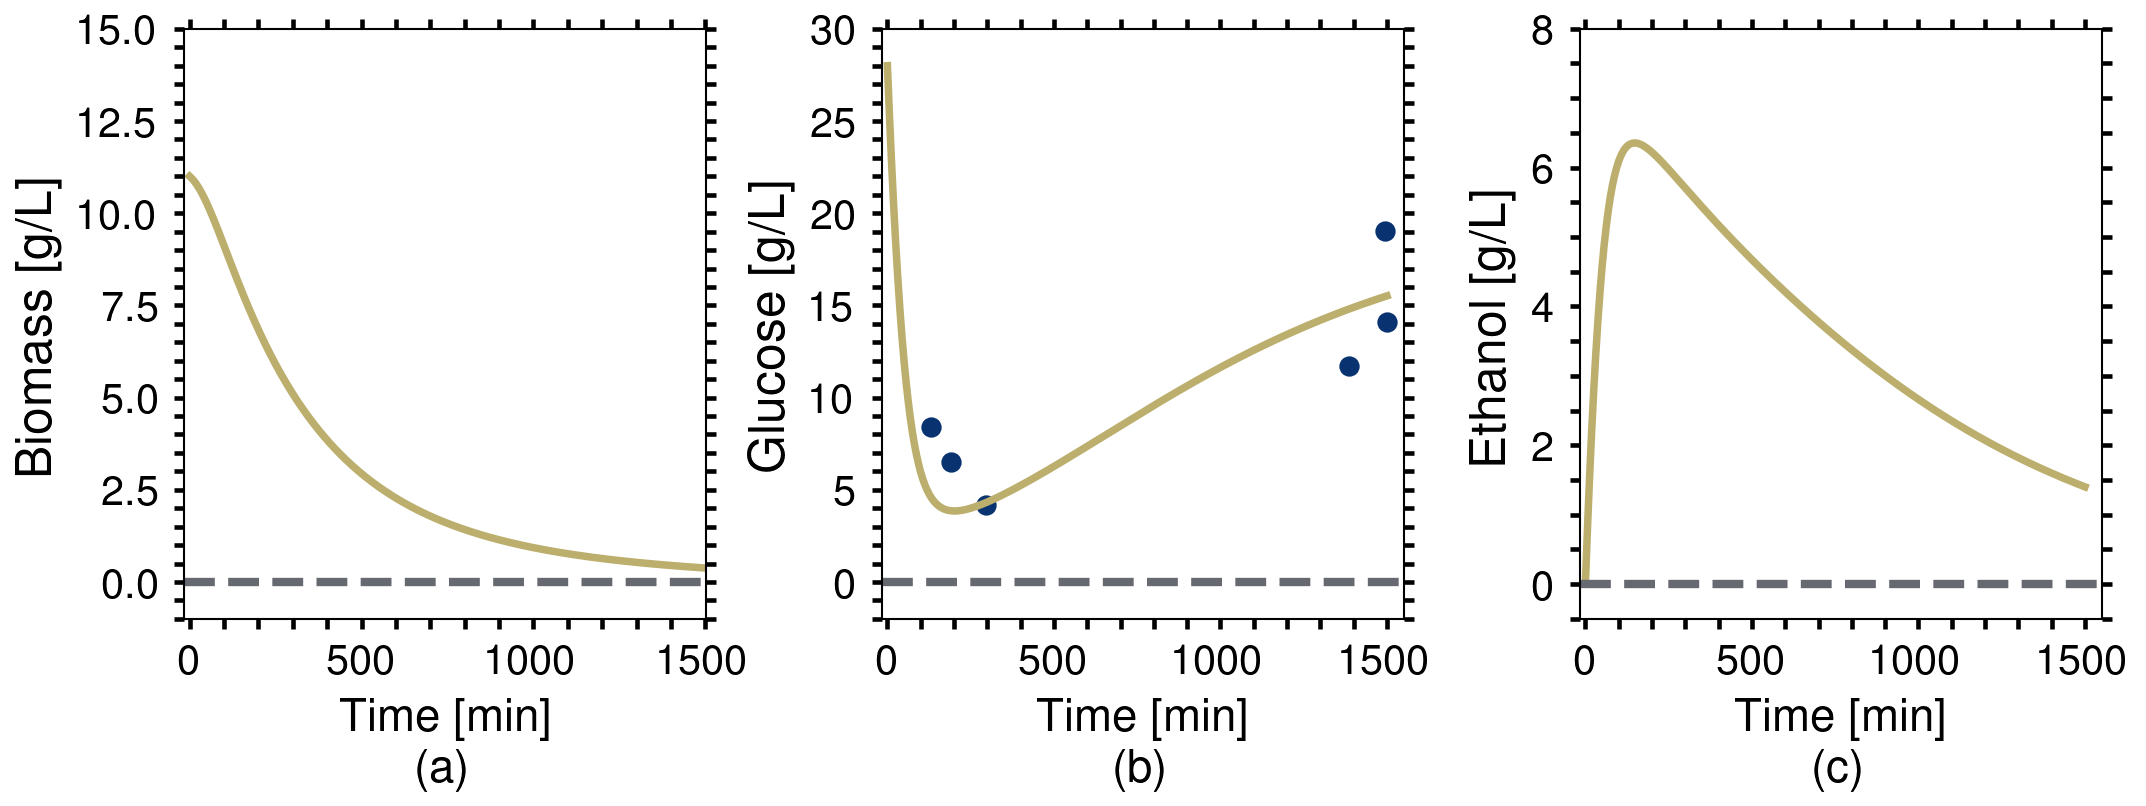

In [ ]:
"""Plot Validation Run"""

# use scienceplots
plt.style.use(['science','nature'])

# use cividis cmap
cmap = sb.color_palette('cividis', as_cmap=True)

# plot for biomass, glucose, and ethanol
fig, (a1, a2, a3) = plt.subplots(figsize=(7.2, 2.8), nrows = 1, ncols = 3)

# axes 1: Biomass
a1.plot(sol.ts, sol.ys[:,0], linewidth=1.8, color=cmap(0.75))
a1.axhline(0, ls='--', lw=2, color=cmap(0.4))
a1.set_xlim(-15, 1501)
a1.set_ylim(-1, 15)
a1.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a1.set_xlabel('Time [min] \n (a)', fontsize=11.0)
a1.set_ylabel('Biomass [g/L]', fontsize=12.0)

# axes 2: glucose
a2.plot(sol.ts, sol.ys[:,1], linewidth=1.8, color=cmap(0.75))
a2.scatter(validation_run['Time'], validation_run['Sugar_Conc'], s=15, color=cmap(0.1))
a2.axhline(0, ls='--', lw=2, color=cmap(0.4))
a2.set_xlim(-15, 1550)
a2.set_ylim(-2, 30)
a2.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a2.set_xlabel('Time [min] \n (b)', fontsize=11.0)
a2.set_ylabel('Glucose [g/L]', fontsize=12.0)

# axes 3: ethanol
a3.plot(sol.ts, sol.ys[:,2], linewidth=1.8, color=cmap(0.75))
a3.axhline(0, ls='--', lw=2, color=cmap(0.4))
a3.set_xlim(-15, 1550)
a3.set_ylim(-0.5, 8)
a3.tick_params(which='both', direction='out', length=2.5, width=1.1, labelsize=10.0)
a3.set_xlabel('Time [min] \n (c)', fontsize=11.0)
a3.set_ylabel('Ethanol [g/L]', fontsize=12.0)

plt.grid(False)
plt.tight_layout()

#plt.savefig('plots_svg/validation.svg') # save as .svg
#plt.savefig('plots_eps/validation.eps') # save as .eps
plt.show()

In [ ]:
# get validation sol again, but save at sampling points
preds_res = diffeqsolve(
        MonodTerm, 
        solver, 
        t0=val_data['ts'][0], # Start time
        t1=val_data['ts'][-1], # End time
        dt0=1.0,        
        y0=val_data['y0'], # Initial biological concentrations [X0, S0, P0]
        stepsize_controller=stepsize_controller,
        args=val_args,        
        saveat=SaveAt(ts=val_data['ts']), 
        max_steps=10_000
    )

# get validation residuals 
monod_val_residuals = validation_run['Sugar_Conc'] - preds_res.ys[:,1]

# get metrics
get_model_metrics(monod_val_residuals, monod_params_opt)

RMSE: 8.381
MAE: 5.097
AIC: 33.512
BIC: 32.679
